# KPS — paper-ready results

Every asset here is produced from the **generation campaign already on disk**; nothing re-runs a
sampler. Tables are written as `.tex` fragments and figures as vector `.pdf` into
`notebooks/paper/`, ready for `\input{}` and `\includegraphics{}`.

| what | where |
|---|---|
| experiment configuration (appendix) | `tab_config.tex`, `tab_sampler.tex` |
| benchmark table, per problem | `tab_bench_<problem>.tex` |
| distributional metrics | `tab_posterior.tex`, `tab_posterior_median.tex` |
| metrics vs ensemble size | `fig_particles.pdf` |
| main-text gallery | `fig_multimodal_row_id46.pdf` |
| appendix galleries | `fig_samples_<problem>.pdf` |

---
## 0. Provenance — read before quoting any number

Three facts established from git history and the runs' own stored `config.yaml`. They are not
caveats to bury; two of them change what may be claimed.

1. **Black hole uses a different measurement model from the published benchmark.** Commit
   `b93dfbb` (2026-09-17) switched `noise_type` from `'eht'` to `'vis_thermal'` so the Jacobian
   variant could run, and the campaign ran after it. This changes the *measurement model*, not
   just the solver. **Decision: the blackhole results are reported, and the paper states the
   change.** The caveat is emitted as a LaTeX comment inside `tab_bench_blackhole.tex` itself,
   so it travels with the fragment rather than depending on this notebook being read.
2. **Navier–Stokes uses `sigma_noise = 1e-4`**, not the benchmark's `0.0` (our commit
   `ab79ef2`). Disclose it; earlier measurement found results flat in this setting.
3. **Inverse scattering matches upstream exactly**, so its rows are directly comparable.

A fourth, about KPS-H only: the campaign ran 2026-09-17/18 and the solve fix landed 09-21, so
every **KPS-H** number here predates it. A paired A/B at 3 instances found the fix
benchmark-neutral, and **KPS-G is unaffected** (its GMRES never divides by `sigma_y`). The
blackhole KPS-H divergences below are the most likely thing the fix would change.

In [1]:
import sys, pathlib, importlib, pickle
sys.path.insert(0, '/mnt/home/gandry/kps/InverseBench/scripts')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import paper_assets as pa
importlib.reload(pa)

OUT = pathlib.Path('/mnt/home/gandry/kps/InverseBench/notebooks/paper')
OUT.mkdir(parents=True, exist_ok=True)

def emit(name, tex):
    (OUT / name).write_text(tex + '\n')
    print(f'--- {name} ' + '-' * (62 - len(name)))
    print(tex)

df = pa.load_metrics()
print(df.groupby(['problem', 'algo', 'n']).size().rename('instances').to_string())

problem        algo  n  
blackhole      KPSG  16     100
               KPSH  64     100
                     128    100
                     256    100
                     512    100
inv-scatter    KPSG  16     100
               KPSH  64     100
                     128    100
                     256    100
                     512    100
navier-stokes  KPSH  64      10
                     128     10
                     256     10
                     512     10


## Method overview

One sweep of the ladder. KPS-G and KPS-H differ in stage 3 only.


In [ ]:
# ---- METHOD FIGURE ------------------------------------------------------
# Pure schematic: no data, so it needs no cache and no campaign. The numbers on it
# are the production settings in tab_sampler.tex, so if that table changes this
# figure is stale and the docstring says which lines to touch.
pa.fig_method(out=OUT / 'fig_method.pdf')
pa.fig_method(out=OUT / 'fig_method.png')
plt.show()

## 1. Experiment configuration (appendix)

Read from each run's **stored** `config.yaml`, so the table describes what produced the numbers
rather than the config files as they read today. `Test instances` is taken from the scored
results, not the config: the campaign was sharded over an array job, so each stored config
records only its own shard.

In [2]:
emit('tab_config.tex', pa.config_table(df))
emit('tab_sampler.tex', pa.sampler_table())

--- tab_config.tex ------------------------------------------------
\small
\setlength{\tabcolsep}{4pt}
\sloppy
\begin{tabular}{@{}p{0.17\linewidth}p{0.28\linewidth}p{0.06\linewidth}p{0.22\linewidth}p{0.11\linewidth}@{}}
\toprule
Problem & Forward model & $\sigma_{\text{noise}}$ & Prior & Instances \\
\midrule
\raggedright\sloppy Black-hole imaging & \raggedright\sloppy EHT visibilities, 64$\times$64 image, \texttt{vis\_thermal} noise, \texttt{direct} transform & 0 & \raggedright\sloppy \texttt{\scriptsize blackhole-50k} & 100 (0--99) \\
\raggedright\sloppy Inverse scattering & \raggedright\sloppy 128$\times$128 permittivity, 20 transmitters $\times$ 360 receivers, wavenumber 6 & 0.0001 & \raggedright\sloppy \texttt{\scriptsize inv-scatter-5m} & 100 (0--99) \\
\raggedright\sloppy Navier--Stokes & \raggedright\sloppy vorticity at $t=1.0$, Re${}=200.0$, 128$^2$ downsampled $\times$2 & 0.0001 & \raggedright\sloppy \texttt{\scriptsize ns-5m} & 10 (0--9) \\
\bottomrule
\end{tabular}


--- tab_sampler.tex -----------------------------------------------
\begin{tabular}{llrrrrrrrr}
\toprule
Variant & Slope & $N$ & $T$ & $M$ & $r$ & Krylov & ODE & $\sigma_{\max}$ & $\sigma_{\min}$ \\
\midrule
KPS-G & averaged Jacobian & 16 & 32 & 2 & -- & 8 & 4 & 80 & 0.05 \\
KPS-H & ensemble regression & 64 & 32 & 2 & 32 & -- & 4 & 80 & 0.05 \\
KPS-H & ensemble regression & 128 & 32 & 2 & 32 & -- & 4 & 80 & 0.05 \\
KPS-H & ensemble regression & 256 & 32 & 2 & 32 & -- & 4 & 80 & 0.05 \\
KPS-H & ensemble regression & 512 & 32 & 2 & 32 & -- & 4 & 80 & 0.05 \\
\bottomrule
\end{tabular}


## 2. Benchmark table

InverseBench's own evaluator on our arms. Baseline rows are left as **explicit placeholders**:
no baseline was run at this scale locally (the experiment tree holds 4 EnKG results on
Navier–Stokes and none elsewhere), so those numbers must come from the benchmark paper. Do not
paste the blackhole table into a comparison against published `eht` numbers — see §0.

### 2a. Main text — ours beside the benchmark's best

Top-3 published methods per problem, one headline metric each, plus the three posterior
columns no baseline reports. The cells below 2b are the full per-problem fields (appendix).


In [ ]:
# ---- MAIN-TEXT TABLE ----------------------------------------------------
# WIDE, NOT TALL: problems are column groups, so it is 4 rows and 384pt -- inside a
# 397pt ICLR column, checked by compiling. As row blocks the same content ran half a
# page. Trimmed for the main text (no N column, no sd, no skill, no footnote block);
# the caption carries what the table cannot and the appendix carries the rest.
emit('tab_main.tex', pa.main_table(df))
emit('tab_main_caption.tex', pa.main_caption(df))
print(pa.main_table(df))

In [3]:
for prob in ('inv-scatter', 'navier-stokes', 'blackhole'):
    if not (df.problem == prob).any():
        continue
    emit(f'tab_bench_{prob}.tex', pa.benchmark_table(df, prob))
    emit(f'tab_bench_{prob}_median.tex', pa.benchmark_table(df, prob, stat='median'))

--- tab_bench_inv-scatter.tex -------------------------------------
\small
\begin{tabular}{llcc}
\toprule
Method & $N$ & PSNR $\uparrow$ & SSIM $\uparrow$ \\
\midrule
\multicolumn{4}{l}{\emph{published baselines (InverseBench, Table 3, 360 receivers)}} \\
FISTA-TV & -- & $32.13$ & $0.9790$ \\
DDRM & -- & $32.60$ & $0.9290$ \\
DDNM & -- & $36.38$ & $0.9350$ \\
$\Pi$GDM & -- & $27.93$ & $0.8890$ \\
DPS & -- & $32.06$ & $0.8460$ \\
LGD & -- & $27.90$ & $0.8120$ \\
DiffPIR & -- & $34.24$ & $0.9880$ \\
PnP-DM & -- & $33.91$ & $0.9880$ \\
DAPS & -- & $34.64$ & $0.9570$ \\
RED-diff & -- & $36.56$ & $0.9810$ \\
FPS & -- & $33.24$ & $0.8700$ \\
MCG-diff & -- & $30.94$ & $0.7510$ \\
\midrule
\multicolumn{4}{l}{\emph{this work}} \\
KPS-G & 16 & $39.52 \pm 2.90$ & $0.9962 \pm 0.0023$ \\
KPS-H & 64 & $20.53 \pm 4.49$ & $0.7649 \pm 0.1382$ \\
KPS-H & 128 & $21.38 \pm 4.92$ & $0.7846 \pm 0.1388$ \\
KPS-H & 256 & $21.80 \pm 5.41$ & $0.7753 \pm 0.1592$ \\
KPS-H & 512 & $21.64 \pm 5.81$ & $0.7559 \pm 0.

## 3. Distributional metrics

The claim the benchmark metrics cannot express. Two versions are emitted because blackhole
KPS-H's SSR standard deviation reaches 5.2 — a few near-divergent instances carry an enormous
spread ratio while their *mean* stays fine, so the `x_mean_l2` filter does not catch them.
**Quote the median/IQR table wherever the mean±sd table shows an sd larger than its mean.**

`failures` counts instances with relative error above 2, i.e. runs that blew up rather than ran
badly. How often a method fails is itself a result and is not averaged away.

In [4]:
emit('tab_posterior.tex', pa.posterior_table(df))
emit('tab_posterior_median.tex', pa.posterior_table_median(df))

fail = (df.assign(bad=df.x_mean_l2 > pa.DIVERGED)
          .groupby(['problem', 'algo', 'n']).bad.agg(['sum', 'size']))
print('\nfailures / instances:')
print(fail[fail['sum'] > 0].to_string())

--- tab_posterior.tex ---------------------------------------------
\small
\begin{tabular}{llccccc}
\toprule
Method & $N$ & \shortstack{particle\\RMSE $\downarrow$} & \shortstack{skill\\$\downarrow$} & \shortstack{CRPS\\$\downarrow$} & \shortstack{spread-skill\\ratio $\to 1$} & \shortstack{90\% coverage\\$\to 0.9$} \\
\midrule
\multicolumn{7}{l}{\itshape Black-hole imaging} \\
KPS-G & 16 & $0.703 \pm 0.202$ & $0.552 \pm 0.175$ & $0.1407 \pm 0.0506$ & $0.964 \pm 0.201$ & $0.788 \pm 0.116$ \\
KPS-H & 64 & $0.511 \pm 0.344$ & $0.510 \pm 0.344$ & $0.1840 \pm 0.1229$ & $0.065 \pm 0.031$ & $0.249 \pm 0.164$ \\
KPS-H & 128 & $0.457 \pm 0.323$ & $0.454 \pm 0.323$ & $0.1591 \pm 0.1084$ & $0.124 \pm 0.093$ & $0.374 \pm 0.198$ \\
KPS-H & 256 & $0.485 \pm 0.418$ & $0.439 \pm 0.279$ & $0.1515 \pm 0.1116$ & $0.820 \pm 5.207$ & $0.545 \pm 0.177$ \\
KPS-H & 512 & $0.482 \pm 0.355$ & $0.441 \pm 0.294$ & $0.1471 \pm 0.1165$ & $0.638 \pm 2.341$ & $0.658 \pm 0.153$ \\
\midrule
\multicolumn{7}{l}{\itshape 

## 4. Metrics against ensemble size

Median over instances with a bootstrap 95% interval. KPS-G ran at a single ensemble size and is
drawn as a point, not a line, so it is not read as a trend.

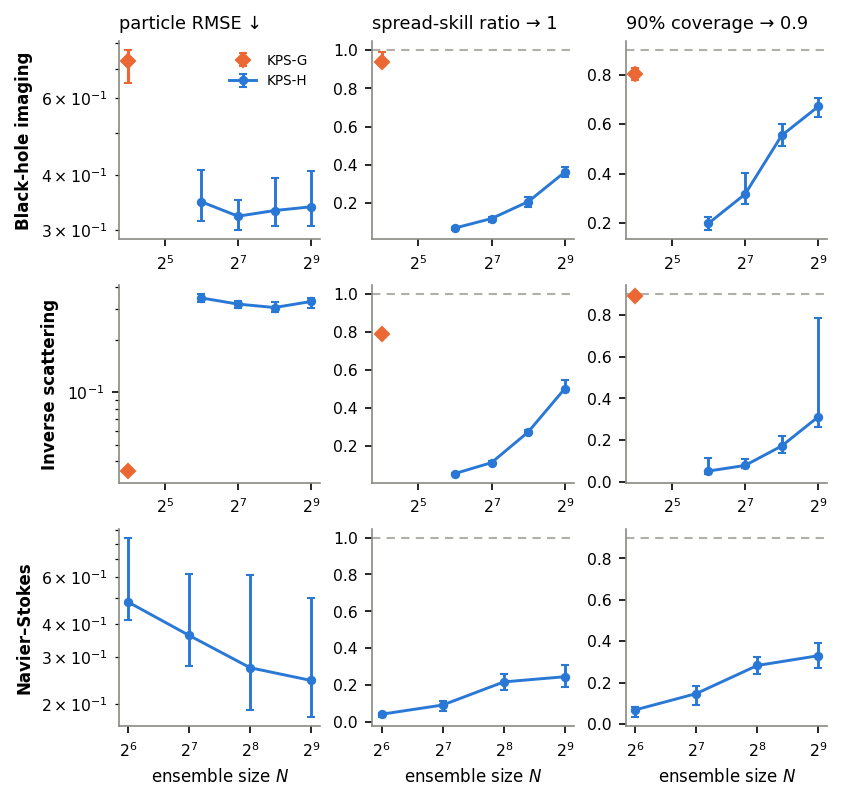

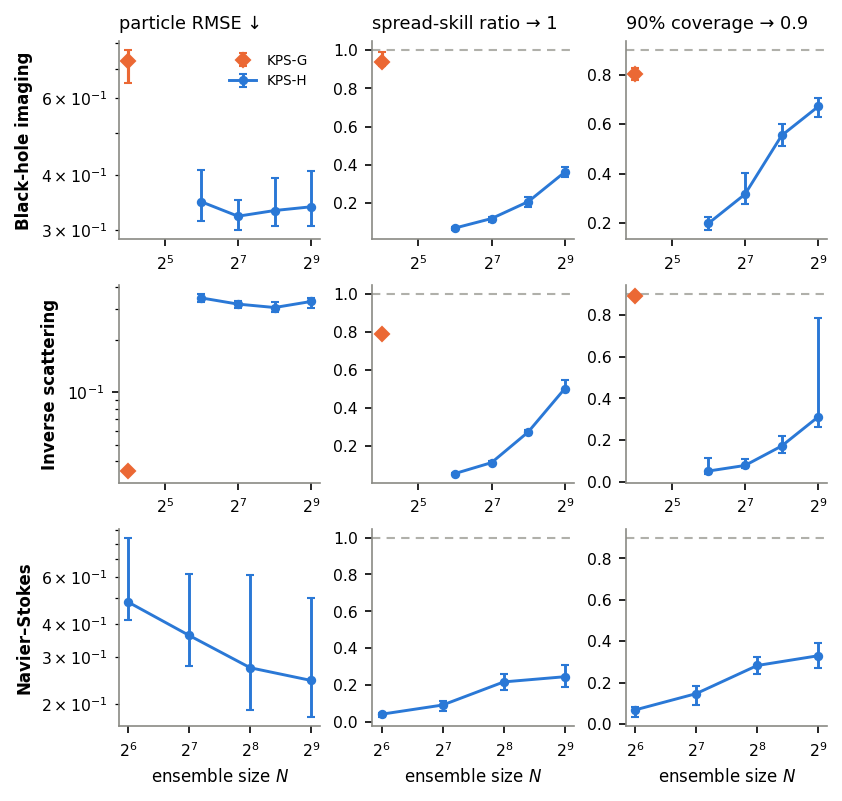

In [5]:
fig = pa.fig_particles(df, OUT / 'fig_particles.pdf')
pa.fig_particles(df, OUT / 'fig_particles.png')
plt.show()

## 5. Main-text gallery

Kept deliberately small. The uncertainty panels share **one** colour scale across ensemble
sizes: scaling each panel to itself would hide the very effect being shown.

In [ ]:
plt.show()

### Multimodality

The instance is **chosen by a stated statistic, not by eye**: a 2-means separation over
within-cluster spread in the ensemble's top-2 principal plane. Members are then split by the
sign of their first principal component. The ensemble mean is shown on purpose — it is the
average of two incompatible images and resembles neither, which is the argument that a point
estimate cannot represent this posterior.

In [ ]:
rank = pa.scan_bimodal('blackhole', 'KPSH', 'gen_N512')
print('most bimodal instances (score, id):', [(round(b, 1), i) for b, i in rank[:5]])
print('least:', [(round(b, 1), i) for b, i in rank[-3:]])

# id 46 is the top-ranked instance; fixed explicitly so the figure is reproducible.
# (id 68 scores as high but one of its 'modes' is a DIVERGED member, not a mode.)
# ONE ROW: truth | y(truth) | mode A | y(mode A) | mode B | y(mode B). Three candidate
# instances; 46 is the most visually distinct but its minority mode fits the closure phases
# 6x worse than the truth, 38 is the most even, 68 is in between. See the docstring.
for _i in (46, 38, 68):
    pa.fig_multimodal_row(idx=_i, show_cp=True, out=OUT / f'fig_multimodal_row_id{_i}.pdf')
    pa.fig_multimodal_row(idx=_i, show_cp=True, out=OUT / f'fig_multimodal_row_id{_i}.png')
    plt.show()
plt.show()

## 6. Appendix galleries — individual members

A mean and a standard deviation cannot show two modes; they average them into a blur with a
wide error bar. Only the members can.

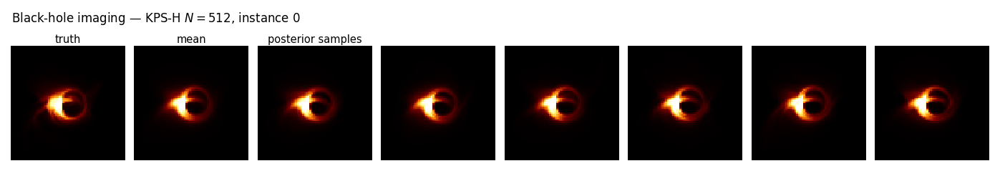

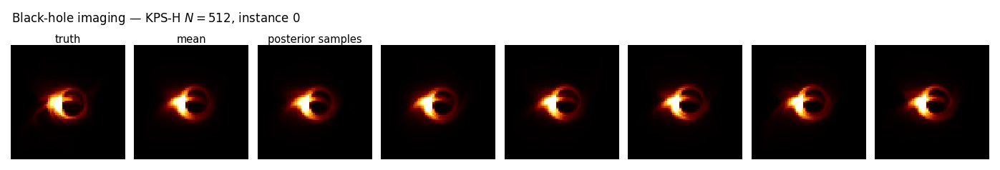

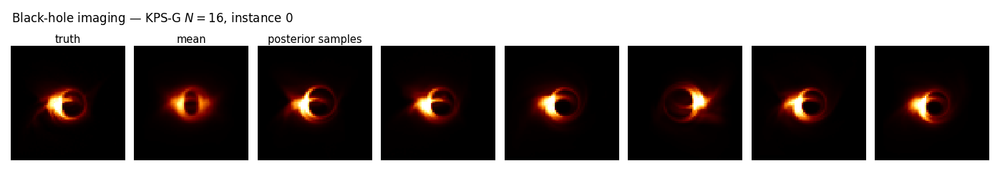

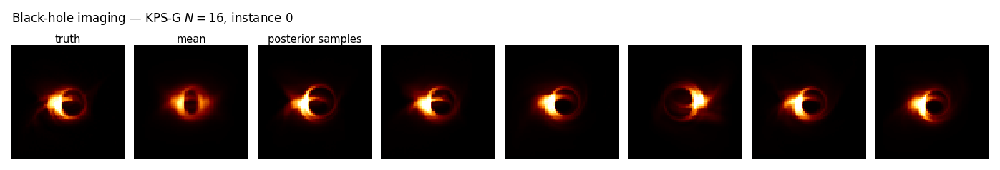

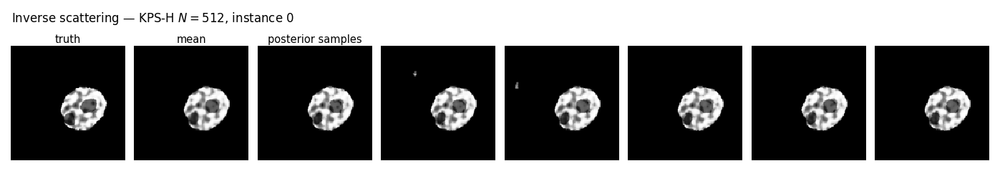

...

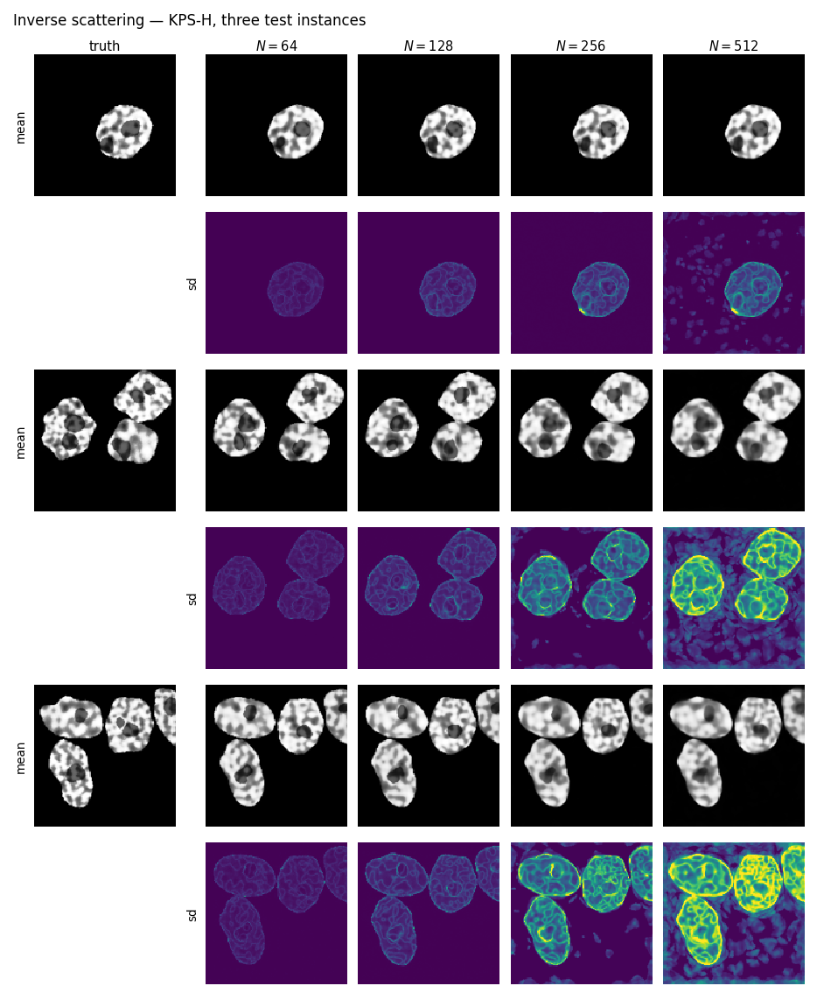

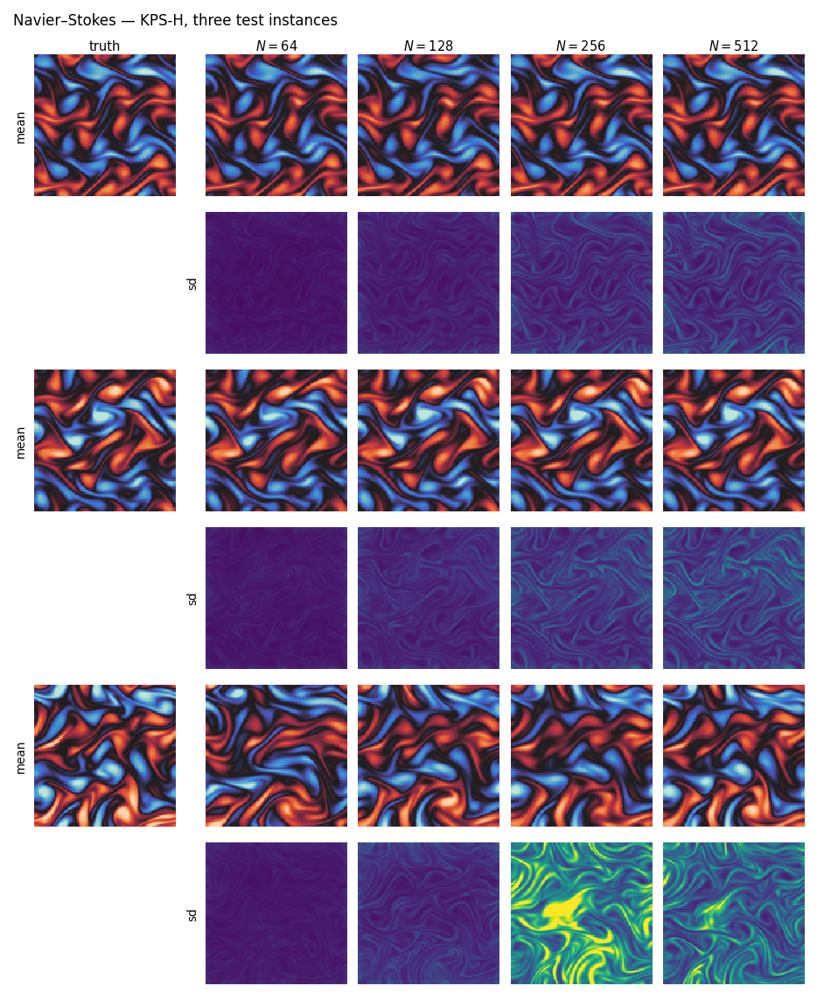

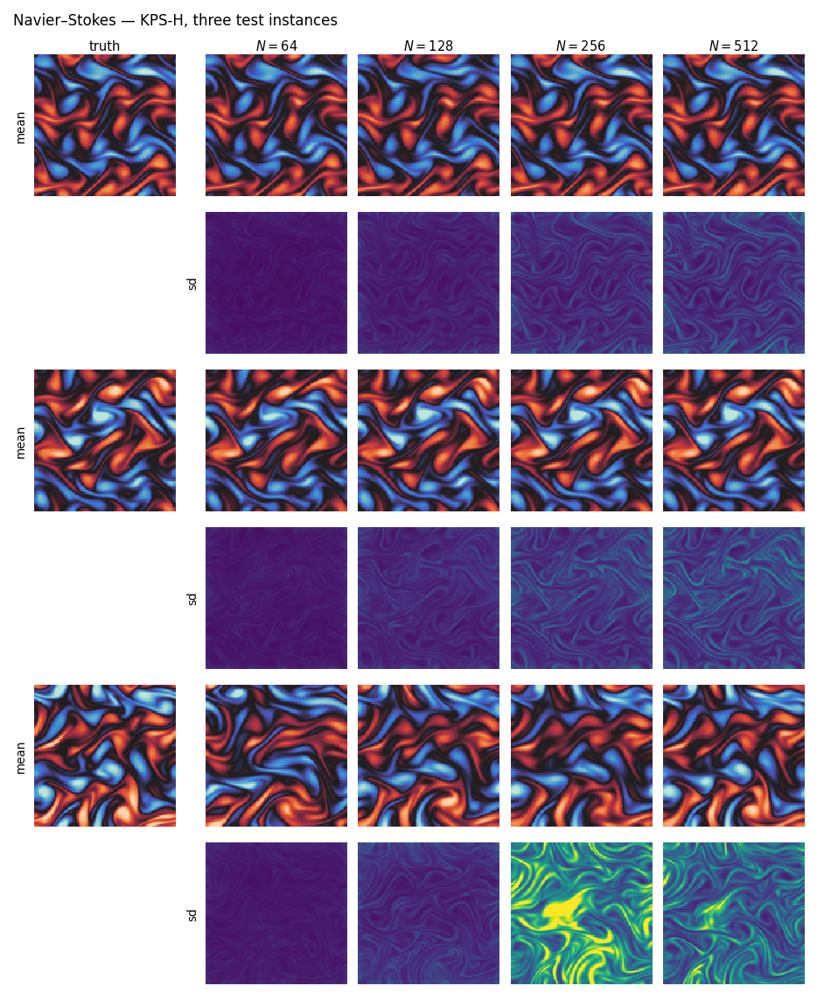

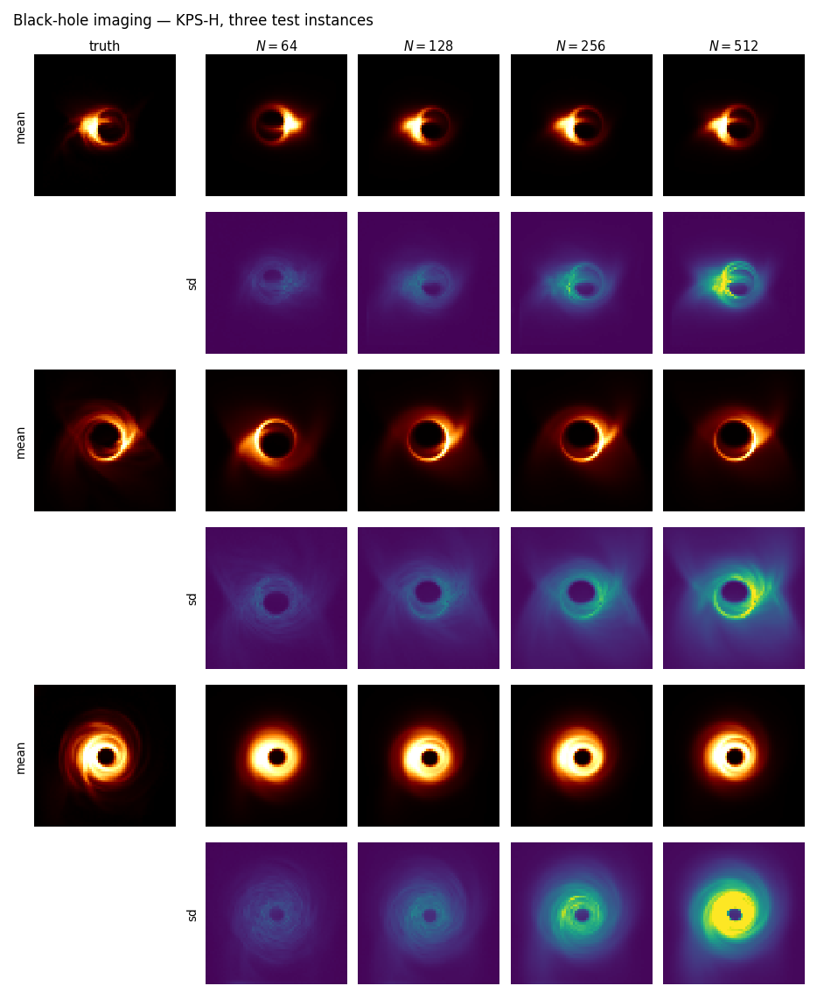

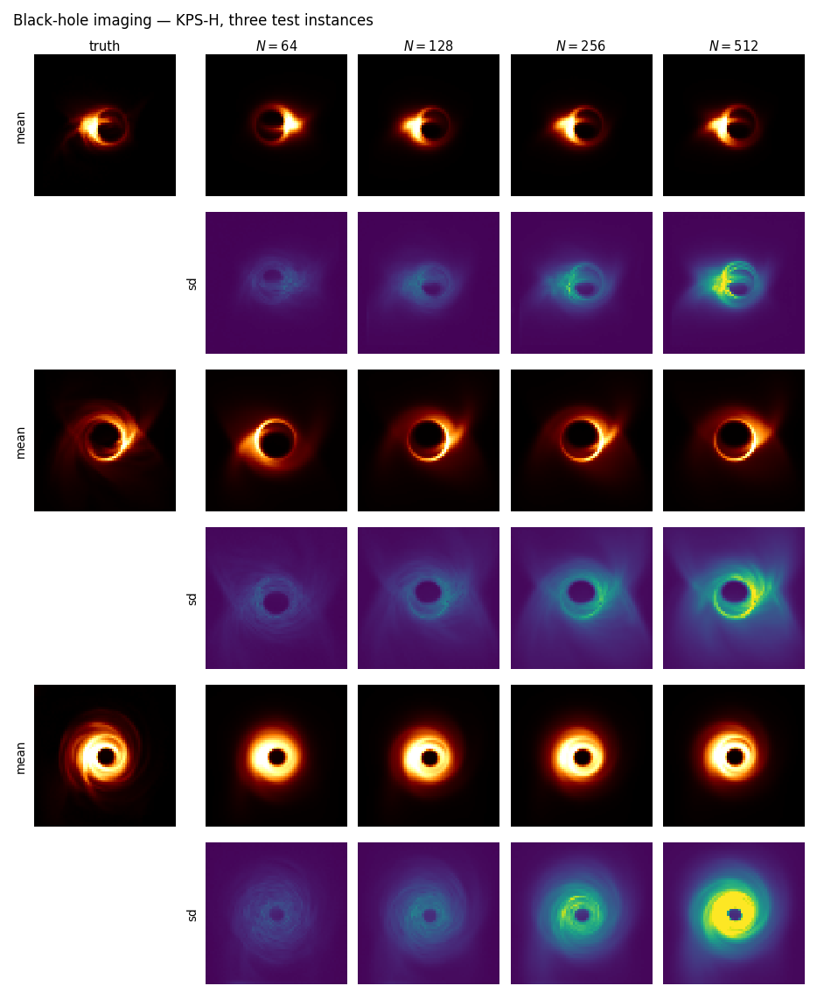

In [8]:
PICKS = [('blackhole', 'KPSH', 'gen_N512'), ('blackhole', 'KPSG', 'gen'),
         ('inv-scatter', 'KPSH', 'gen_N512'), ('inv-scatter', 'KPSG', 'gen'),
         ('navier-stokes', 'KPSH', 'gen_N512')]
for prob, algo, run in PICKS:
    try:
        f = pa.fig_gallery_samples(prob, algo, run, idx=0, k=6,
                                   out=OUT / f'fig_samples_{prob}_{algo}.pdf')
        pa.fig_gallery_samples(prob, algo, run, idx=0, k=6,
                               out=OUT / f'fig_samples_{prob}_{algo}.png')
        plt.show()
    except Exception as e:
        print(f'{prob}/{algo}/{run}: {type(e).__name__}: {e}')

# SEVERAL INSTANCES, several members each -- one row per instance. A single instance cannot
# show that different instances fail in different ways.
for prob, algo, run in PICKS:
    try:
        pa.fig_gallery_instances(prob, algo, run, ids=(0, 1, 2, 3), k=4,
                                 out=OUT / f'fig_instances_{prob}_{algo}.pdf')
        pa.fig_gallery_instances(prob, algo, run, ids=(0, 1, 2, 3), k=4,
                                 out=OUT / f'fig_instances_{prob}_{algo}.png')
        plt.show()
    except Exception as e:
        print(f'{prob}/{algo}/{run}: {type(e).__name__}: {e}')

# WHAT MORE PARTICLES BUY, over several instances. The sd panels share one colour scale across
# every N and every instance shown: scaling each panel to itself would make all ensembles look
# equally uncertain and hide the growth this figure exists to show.
for prob in ('inv-scatter', 'navier-stokes', 'blackhole'):
    pa.fig_growth(prob, out=OUT / f'fig_growth_{prob}.pdf')
    pa.fig_growth(prob, out=OUT / f'fig_growth_{prob}.png')
    plt.show()

## 7. TARP

`KPS/kps/metrics.py:TARP` needs a *callable* posterior sampler, which an amortised estimator has
and a stored campaign does not, so the statistic is recomputed here from stored ensembles:

$$ f_i = \frac{1}{N}\sum_j \mathbf{1}\!\left[\lVert x_{ij}-r_i\rVert < \lVert x_i^\star-r_i\rVert\right],
\qquad \mathrm{ECP}(\alpha) = \frac{1}{M}\sum_i \mathbf{1}[f_i \le \alpha]. $$

The credible region at level $\alpha$ is the ball about $r$ holding $\alpha$ of the posterior
mass, so the truth lies inside exactly when $f_i \le \alpha$; under correct sampling $f$ is
uniform and the curve is the diagonal.

**The estimator is validated first.** An earlier version of this self-test reported the
calibrated case as badly over-dispersed — the fault was the *test*, which centred the ensemble
on the truth and so made the truth artificially central. The truth must be a draw from the same
posterior as the members.

In [9]:
res = pa.tarp_selftest()
print(f"{'case':<22}{'max above':>12}{'max below':>12}{'rms dev':>10}")
for k, (a, c, hi, lo) in res.items():
    print(f'{k:<22}{hi:>+12.3f}{lo:>+12.3f}{np.sqrt(((c - a) ** 2).mean()):>10.3f}')
print('\nexpected: calibrated ~0 on both; x2 strongly +; x0.5 strongly -')

case                     max above   max below   rms dev
calibrated                  +0.026      -0.002     0.016
over-dispersed x2           +0.947      +0.000     0.570
over-confident x0.5         +0.001      -0.734     0.474

expected: calibrated ~0 on both; x2 strongly +; x0.5 strongly -


In [ ]:
JOBS = [('blackhole', 'KPSG', 'gen', range(100)),
        ('blackhole', 'KPSH', 'gen_N512', range(100)),
        ('inv-scatter', 'KPSG', 'gen', range(100)),
        ('inv-scatter', 'KPSH', 'gen_N512', range(100)),
        ('navier-stokes', 'KPSH', 'gen_N512', range(10))]

# THE PARTICLE LADDER, not one N per arm: KPS-H is stored at N=64..512 on all three problems,
# and the TARP curve moving with N is the point -- none of them reaches the diagonal, but they
# approach it monotonically, which a single curve cannot show. ~30s per curve.
TARP_JOBS = [(p, 'KPSH', f'gen_N{n}', n)
             for p in ('blackhole', 'inv-scatter', 'navier-stokes')
             for n in (64, 128, 256, 512)]
TARP_JOBS += [(p, 'KPSG', 'gen', 16) for p in ('blackhole', 'inv-scatter')]

cache = OUT / 'tarp_ladder.pkl'
if cache.exists():
    curves = pickle.load(open(cache, 'rb'))
else:
    curves = []
    for prob, algo, run, N in TARP_JOBS:
        ids = range(10) if prob == 'navier-stokes' else range(100)
        curves.append((prob, f'{pa.LBL[algo]} N={N}', pa.tarp(prob, algo, run, ids)))
    pickle.dump(curves, open(cache, 'wb'))

print(f"{'problem':<15}{'method':<16}{'rms dev':>9}{'mean f':>9}")
for prob, lab, (a, c, fs) in curves:
    print(f'{prob:<15}{lab:<16}{np.sqrt(((c - a) ** 2).mean()):>9.3f}{fs.mean():>9.3f}')

plt.show()

## 8. MIRA

MIRA (arXiv:2605.02014, `github.com/SammyS15/mira-score`) scores calibration from **paired
samples only** - no density, no evidence integral, no reference posterior. For each ground
truth: draw a random centre, take the radius out to one **held-out** posterior sample, count
how many of the remaining $N$ members fall inside, and score the probability the ensemble
assigned to what actually happened, with Laplace smoothing.

**Why 2/3, and why it does not depend on the dimension:** the held-out sample's distance rank
among the others is uniform when the members are exchangeable, so $p\sim U(0,1)$; and the truth
is exchangeable with the members exactly when the posterior is calibrated, so
$P(\text{inside}\mid p)=p$. Hence $\mathbb{E}[\text{score}]=\mathbb{E}[p^2+(1-p)^2]=2/3$. An
ensemble unrelated to the truth gives $1/2$. The centre distribution changes the *power* of the
test, not its reference value.

**Validated before use.** Both miscalibration directions must fall below 2/3 and the unpaired
case must approach 1/2. An earlier self-test put "unpaired" at 0.64 - because its instances
were not separated enough for a shuffle to mean anything, i.e. a weak *test* rather than a
wrong statistic.

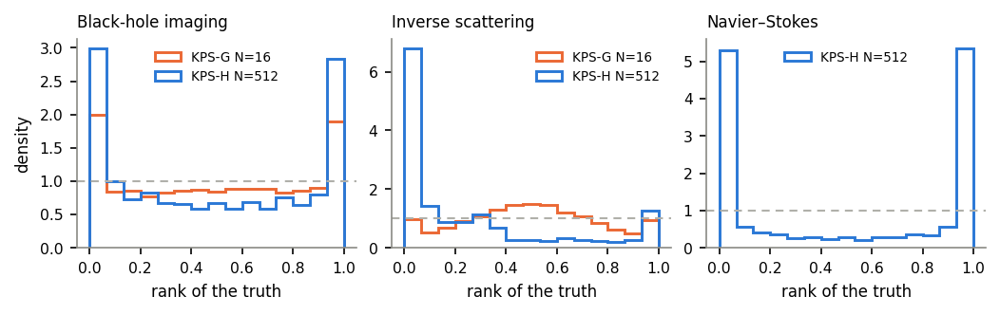

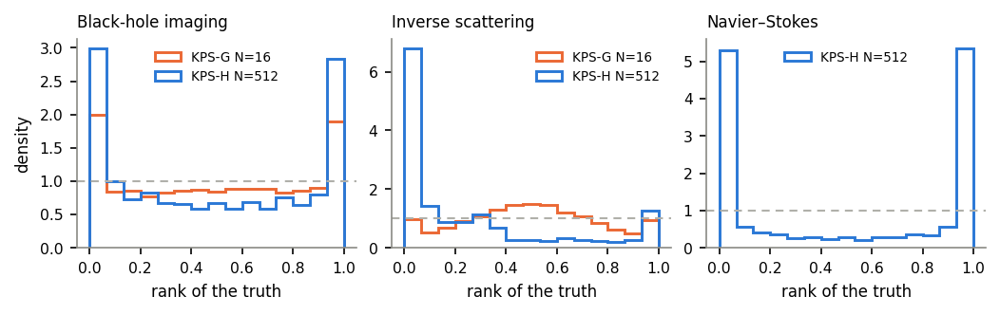

problem        method           frac at edges   (0.10 = flat = calibrated)


blackhole      KPS-G N=16               0.142


blackhole      KPS-H N=512              0.355


inv-scatter    KPS-G N=16               0.071


inv-scatter    KPS-H N=512              0.485


navier-stokes  KPS-H N=512              0.686


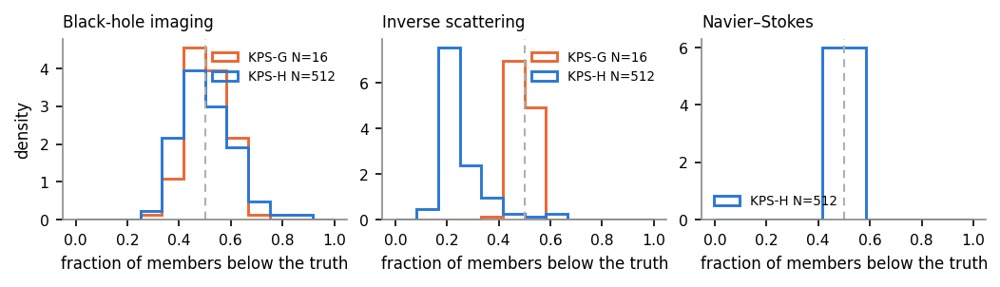


above: MEAN BIAS, not dispersion — 0.5 is unbiased, away from 0.5 is a shifted mean

case                         MIRA     std   expected
calibrated (->0.667)       0.6604  0.0200   0.667
over-confident x0.3        0.5679  0.0238   < 0.667
over-dispersed x3          0.6064  0.0224   < 0.667
unpaired (->0.5)           0.5516  0.0245   0.500

problem        method               MIRA     std  inst   (0.667 calibrated, 0.5 uncalibrated)
blackhole      KPS-G N=16         0.6640  0.0210   100
blackhole      KPS-H N=512        0.6146  0.0224   100
inv-scatter    KPS-G N=16         0.6208  0.0254   100
inv-scatter    KPS-H N=512        0.5146  0.0355   100
navier-stokes  KPS-H N=512        0.6092  0.0800    10
--- tab_mira.tex --------------------------------------------------
\begin{tabular}{llcc}
\toprule
Problem & Method & MIRA $\to 2/3$ & instances \\
\midrule
Black-hole imaging & KPS-G N=16 & $0.6640 \pm 0.0210$ & 100 \\
Black-hole imaging & KPS-H N=512 & $0.6146 \pm 0.0224$ & 100 \\
Inv

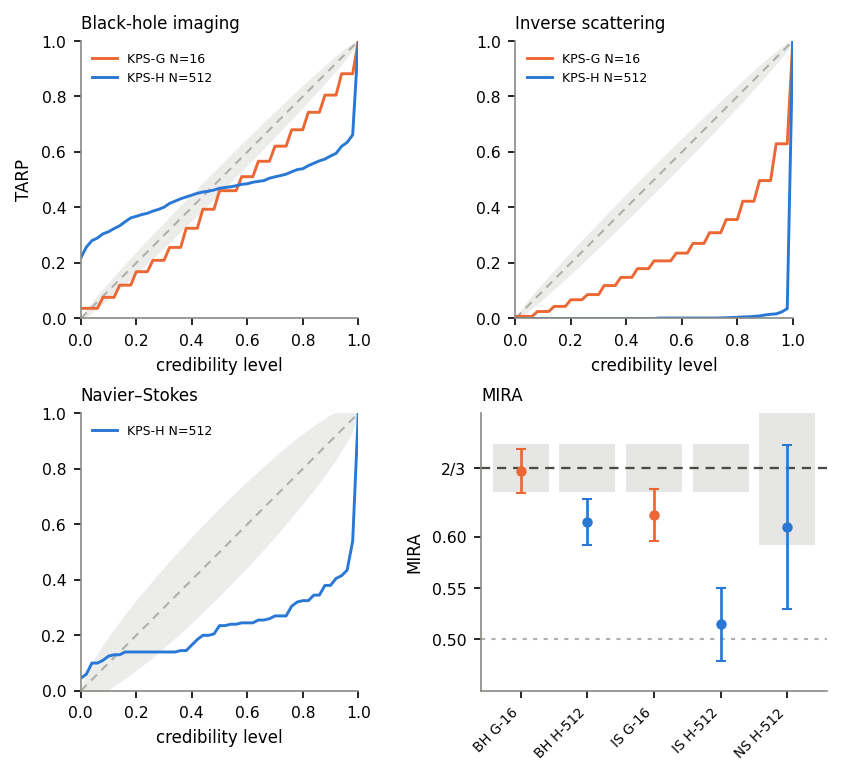

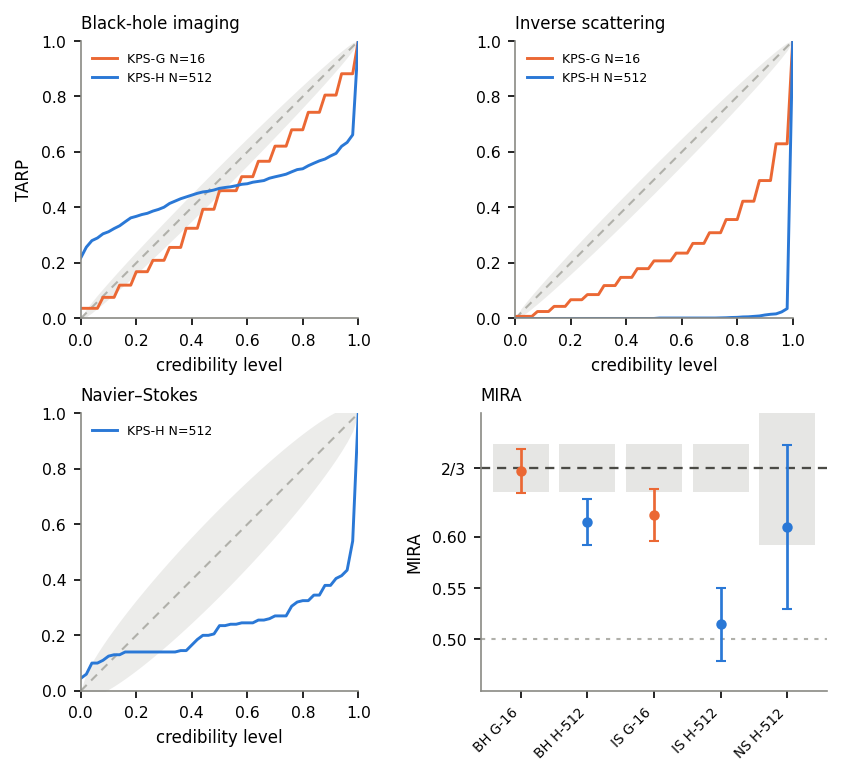

problem        method         |score-2/3|    band   verdict
blackhole      KPS-G N=16          0.0027  0.0236   indistinguishable from calibrated
blackhole      KPS-H N=512         0.0520  0.0236   miscalibrated
inv-scatter    KPS-G N=16          0.0459  0.0236   miscalibrated
inv-scatter    KPS-H N=512         0.1520  0.0236   miscalibrated
navier-stokes  KPS-H N=512         0.0574  0.0745   indistinguishable from calibrated


In [11]:
JOBS = [('blackhole', 'KPSG', 'gen', range(60)),
        ('blackhole', 'KPSH', 'gen_N512', range(60)),
        ('inv-scatter', 'KPSG', 'gen', range(60)),
        ('inv-scatter', 'KPSH', 'gen_N512', range(60)),
        ('navier-stokes', 'KPSH', 'gen_N512', range(10))]

pa.fig_rank(JOBS, out=OUT / 'fig_rankhist.pdf')
pa.fig_rank(JOBS, out=OUT / 'fig_rankhist.png')
plt.show()

print(f"{'problem':<15}{'method':<16}{'frac at edges':>14}   (0.10 = flat = calibrated)")
for prob, algo, run, ids in JOBS:
    r = pa.rank_hist(prob, algo, run, ids)
    N = run.split('_N')[-1] if '_N' in run else '16'
    print(f'{prob:<15}{pa.LBL[algo] + " N=" + N:<16}'
          f'{float(((r < 0.05) | (r > 0.95)).mean()):>14.3f}')

# the cached x_rank, shown for what it actually is
fig, ax = plt.subplots(1, 3, figsize=(6.9, 1.9), squeeze=False)
for a, prob in zip(ax[0], ('blackhole', 'inv-scatter', 'navier-stokes')):
    d = df[(df.problem == prob) & (df.x_mean_l2 <= pa.DIVERGED)]
    for algo, ga in d.groupby('algo'):
        big = ga[ga.n == ga.n.max()]
        a.hist(big.x_rank, bins=12, range=(0, 1), histtype='step', density=True,
               color=pa.C[algo], lw=1.4, label=f'{pa.LBL[algo]} N={int(big.n.iloc[0])}')
    a.axvline(0.5, color='#b0b0aa', ls=(0, (4, 3)), lw=1)
    a.set_title(pa.PLAIN[prob], loc='left', fontsize=8)
    a.set_xlabel('fraction of members below the truth')
    a.legend(fontsize=6.5)
ax[0][0].set_ylabel('density')
plt.savefig(OUT / 'fig_bias.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig_bias.png', bbox_inches='tight')
plt.show()
print('\nabove: MEAN BIAS, not dispersion — 0.5 is unbiased, away from 0.5 is a shifted mean')
# ---- MIRA -----------------------------------------------------------------
print()
print(f"{'case':<24}{'MIRA':>9}{'std':>8}   expected")
_exp = {'calibrated (->0.667)': '0.667', 'over-confident x0.3': '< 0.667',
        'over-dispersed x3': '< 0.667', 'unpaired (->0.5)': '0.500'}
for _k, (_sc, _sd) in pa.mira_selftest().items():
    print(f'{_k:<24}{_sc:>9.4f}{_sd:>8.4f}   {_exp[_k]}')

mira_cache = OUT / 'mira.pkl'
if mira_cache.exists():
    mres = pickle.load(open(mira_cache, 'rb'))
else:
    mres = pa.mira_campaign(JOBS, num_runs=30, max_members=64)
    pickle.dump(mres, open(mira_cache, 'wb'))

print()
print(f"{'problem':<15}{'method':<16}{'MIRA':>9}{'std':>8}{'inst':>6}"
      "   (0.667 calibrated, 0.5 uncalibrated)")
for prob, lab, sc, sd, n in mres:
    print(f'{prob:<15}{lab:<16}{sc:>9.4f}{sd:>8.4f}{n:>6}')

_rows = [r'\begin{tabular}{llcc}', r'\toprule',
         r'Problem & Method & MIRA $\to 2/3$ & instances \\', r'\midrule']
for prob, lab, sc, sd, n in mres:
    _rows.append(f'{pa.NICE[prob]} & {lab} & ${sc:.4f} \\pm {sd:.4f}$ & {n} \\\\')
_rows += [r'\bottomrule', r'\end{tabular}']
emit('tab_mira.tex', '\n'.join(_rows))


# TARP and MIRA on one row. The MIRA band is sqrt(1/(18L)), the spread expected from a FINITE
# number of ground truths: a point inside it is not distinguishable from perfectly calibrated
# at that L. Note NS has L=10, so its band is wide and "inside" means UNDERPOWERED, not
# demonstrated calibrated.
pa.fig_calibration(curves, mres, out=OUT / 'fig_calibration.pdf')
pa.fig_calibration(curves, mres, out=OUT / 'fig_calibration.png')

# No half-column twin any more: the figure is now ONE ROW of four panels, which is a
# full-width object by construction. At 0.5\linewidth each panel would be 0.69in.
# `scale` still works if the type ever needs trimming or growing in place.
plt.show()

print(f"{'problem':<15}{'method':<14}{'|score-2/3|':>12}{'band':>8}   verdict")
for prob, lab, sc, sd, n in mres:
    band = (1 / (18 * n)) ** 0.5
    print(f'{prob:<15}{lab:<14}{abs(sc - 2/3):>12.4f}{band:>8.4f}   '
          f'{"indistinguishable from calibrated" if abs(sc - 2/3) < band else "miscalibrated"}')

## 9. Posterior predictive check (observation space)

Every metric above lives in parameter space. The same ensembles can be scored on how well they
reproduce the **observation**, which separates two quite different failure modes:

- calibrated in $y$, collapsed in $x$ — the ensemble explains the data with an honest spread
  but has lost the width along directions the data does not constrain;
- miscalibrated in both — the ensemble does not even fit the data.

Black hole is the first case and it is striking: KPS-H's observation-space SSR is 0.95–1.09
with 90% coverage 0.84–0.92 at every ensemble size, while its parameter-space SSR is 0.07–0.36.
Inverse scattering and Navier–Stokes are the second case for KPS-H. KPS-G is calibrated in both
spaces on both problems where it ran.

Use the **median** table for black hole: at $N=256$ and $512$ the mean-and-sd version shows an
sd larger than its mean (0.116 ± 0.516), because a few instances that pass the state-space
divergence filter still have wild observation-space errors.

--- tab_ppc.tex ---------------------------------------------------
\small
\begin{tabular}{llcccc}
\toprule
Method & $N$ & \shortstack{particle\\RMSE $\downarrow$} & \shortstack{CRPS\\$\downarrow$} & \shortstack{spread-skill\\ratio $\to 1$} & \shortstack{90\% coverage\\$\to 0.9$} \\
\midrule
\multicolumn{6}{l}{\itshape Black-hole imaging} \\
KPS-G & 16 & $0.0534 \pm 0.0249$ & $0.0113 \pm 0.0052$ & $1.027 \pm 0.121$ & $0.865 \pm 0.013$ \\
KPS-H & 64 & $0.0528 \pm 0.0245$ & $0.0122 \pm 0.0055$ & $0.937 \pm 0.103$ & $0.831 \pm 0.033$ \\
KPS-H & 128 & $0.0519 \pm 0.0253$ & $0.0115 \pm 0.0056$ & $1.019 \pm 0.164$ & $0.869 \pm 0.027$ \\
KPS-H & 256 & $0.1158 \pm 0.5157$ & $0.0131 \pm 0.0158$ & $1.466 \pm 3.096$ & $0.906 \pm 0.031$ \\
KPS-H & 512 & $0.1029 \pm 0.4073$ & $0.0135 \pm 0.0166$ & $1.383 \pm 2.091$ & $0.922 \pm 0.031$ \\
\midrule
\multicolumn{6}{l}{\itshape Inverse scattering} \\
KPS-G & 16 & $0.0155 \pm 0.0051$ & $0.0060 \pm 0.0020$ & $1.075 \pm 0.029$ & $0.834 \pm 0.011$ \\
KPS-H

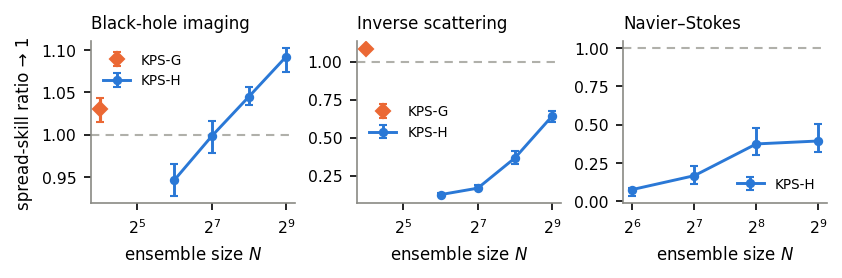

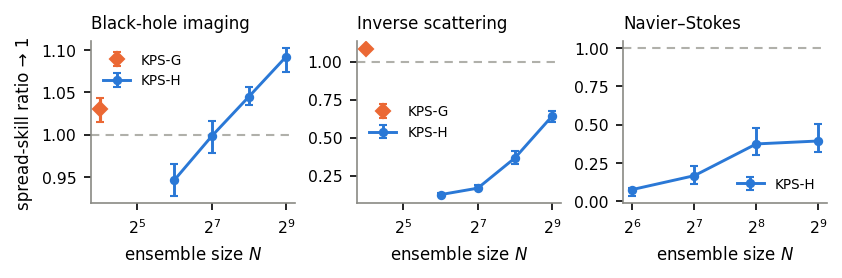

solid = observation space, dashed = parameter space; the gap is the part of the
posterior the data does not constrain.


In [12]:
emit('tab_ppc.tex', pa.ppc_table(df))
emit('tab_ppc_median.tex', pa.ppc_table_median(df))

pa.fig_ppc(df, out=OUT / 'fig_ppc.pdf')
pa.fig_ppc(df, out=OUT / 'fig_ppc.png')
plt.show()
print('solid = observation space, dashed = parameter space; the gap is the part of the')
print('posterior the data does not constrain.')

## 9. What still needs a decision

1. **Baseline numbers** for §2 must come from the benchmark paper; nothing comparable was run
   locally. The blackhole table cannot be used for that comparison at all (§0).
2. **MIRA** needs a definition (§8).
3. **KPS-H blackhole divergences** (up to 4 in 100) predate the solve fix and are the most
   likely thing it would remove. Re-running that arm post-fix would settle it.
4. **KPS-G has no Navier–Stokes row** — its operator was not differentiable when the campaign
   ran. That is now repairable, so the row is obtainable if wanted.